In [ ]:
!ls -lh results

In [1]:
import h5py
import numpy as np
import matplotlib.pylab as plt
import os
%matplotlib widget

In [2]:
test_fn = "results2/test_withLabels.h5"
train_fn = "results2/train.h5"
train_fn = "/home/amir/source/MySynthText/results/SynthText_test.h5"

test_fn_noLabels = "results2/test.h5"

In [3]:
db = h5py.File(train_fn, 'r') 

In [4]:
keys = list(db['data'].keys())

In [5]:
len(keys)

2

In [6]:
im = db['data'][keys[0]][:]

In [7]:
keys

['building_34.jpg_0', 'cows_114.jpg_0']

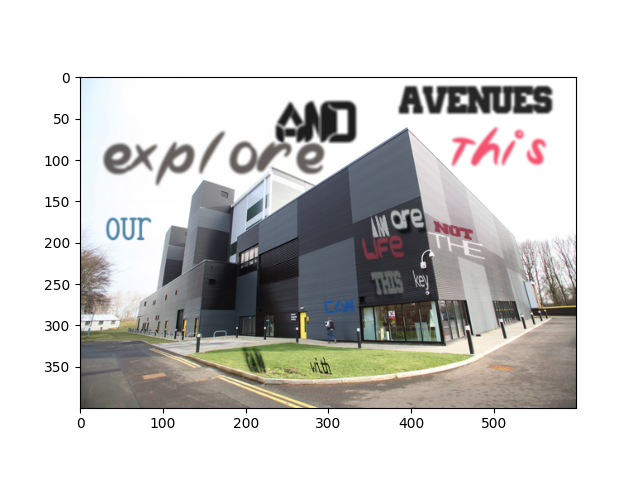

In [8]:
plt.figure()
plt.imshow(im)

In [9]:
# Read fonts.txt into a list
with open('data/fonts/fonts.txt', 'r') as f:
  font_name = [line.strip() for line in f if line.strip()]

print(font_name)
print("num fonts:", len(font_name))

['DEBROSEE', 'Flower Rose Brush', 'FREEDOM', 'Hopkinson', 'Playful Time', 'Skylark', 'Sweet Puppy', 'Ubuntu Mono', 'Wanted M54']
num fonts: 9


In [10]:
color_list = ["r", "b", "y", "k", "m", "w", "g", "r", "b", "y", "k", "m", "w", "g"]

['the' 'life' 'and' 'not' 'key' 'explore' 'with' 'are' 'avenues' 'can'
 'Can' 'this' 'our' 'and' 'This']
['Skylark' 'FREEDOM' 'DEBROSEE' 'Wanted M54' 'Ubuntu Mono' 'Sweet Puppy'
 'Ubuntu Mono' 'FREEDOM' 'Wanted M54' 'DEBROSEE' 'Playful Time'
 'Wanted M54' 'Hopkinson' 'Playful Time' 'Sweet Puppy']
['Skylark' 'Skylark' 'Skylark' 'FREEDOM' 'FREEDOM' 'FREEDOM' 'FREEDOM'
 'DEBROSEE' 'DEBROSEE' 'DEBROSEE' 'Wanted M54' 'Wanted M54' 'Wanted M54'
 'Ubuntu Mono' 'Ubuntu Mono' 'Ubuntu Mono' 'Sweet Puppy' 'Sweet Puppy'
 'Sweet Puppy' 'Sweet Puppy' 'Sweet Puppy' 'Sweet Puppy' 'Sweet Puppy'
 'Ubuntu Mono' 'Ubuntu Mono' 'Ubuntu Mono' 'Ubuntu Mono' 'FREEDOM'
 'FREEDOM' 'FREEDOM' 'Wanted M54' 'Wanted M54' 'Wanted M54' 'Wanted M54'
 'Wanted M54' 'Wanted M54' 'Wanted M54' 'DEBROSEE' 'DEBROSEE' 'DEBROSEE'
 'Playful Time' 'Playful Time' 'Playful Time' 'Wanted M54' 'Wanted M54'
 'Wanted M54' 'Wanted M54' 'Hopkinson' 'Hopkinson' 'Hopkinson'
 'Playful Time' 'Playful Time' 'Playful Time' 'Sweet Puppy' 'Sweet P

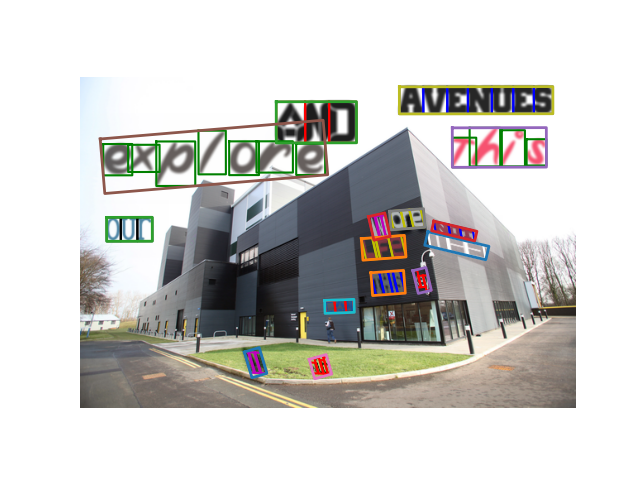

In [11]:
db = h5py.File(train_fn, 'r') 

k = 0
im_data = db["data"][keys[k]]

im = im_data[:]
font_list = im_data.attrs['font']
char_bb = im_data.attrs['charBB']
word_bb = im_data.attrs['wordBB']
text = im_data.attrs['txt']
word_fonts = im_data.attrs['word_font']

nC = char_bb.shape[-1]

plt.figure()
plt.imshow(im)
for b_inx in range(nC):
    c_inx = font_name.index(font_list[b_inx])
    color = color_list[c_inx]
    
    bb = char_bb[:,:,b_inx]
    x = np.append(bb[0,:], bb[0,0])
    y = np.append(bb[1,:], bb[1,0])
    plt.plot(x, y, color)

# plot the word BB
nW = word_bb.shape[-1]
for w_inx in range(nW):
    bb = word_bb[:,:,w_inx]
    x = np.append(bb[0,:], bb[0,0])
    y = np.append(bb[1,:], bb[1,0])
    plt.plot(x, y, lw=2)   

plt.axis('off')
print(text)
print(word_fonts)
print(font_list)

In [12]:
from get_font_paths import get_font_paths_list,read_fonts_txt

In [13]:
read_fonts_txt('/home/amir/source/MySynthText/data/fonts/')

['DEBROSEE',
 'Flower Rose Brush',
 'FREEDOM',
 'Hopkinson',
 'Playful Time',
 'Skylark',
 'Sweet Puppy',
 'Ubuntu Mono',
 'Wanted M54']

pygame 2.6.1 (SDL 2.28.4, Python 3.12.3)
Hello from the pygame community. https://www.pygame.org/contribute.html
(50, 290, 3)
(102, 463, 3)
(33, 338, 3)
(59, 221, 3)
(58, 342, 3)
(63, 422, 3)
(81, 512, 3)
(45, 356, 3)
(51, 435, 3)


/home/amir/miniconda3/envs/cv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


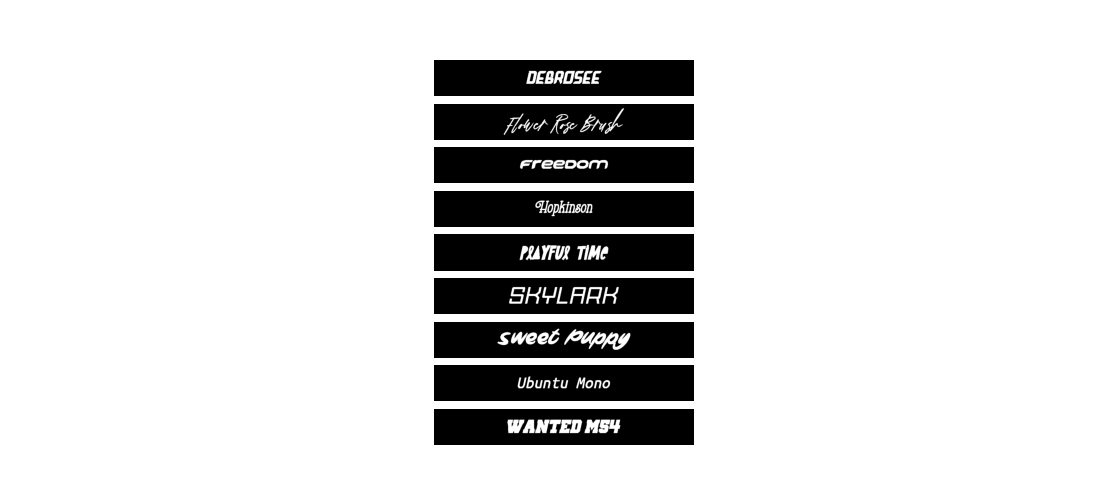

In [14]:
# RENDER_TEXT = "abcdefghijklmnopqrstuvwxyz ABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789`-=~!@#$%^&*()_+[]\\{}|;':\",./<>?"
RENDER_TEXT = "a b c d e f g h i A B C D E F G H I 0 1 2 3 4 5 6 7 8 9"

RENDER_TEXT = ["always forever", "Skylark", "Sweet puppy", "Ubuntu mono", "Vertigo", "Wanted", "Flower Rose Brush"]

RENDER_TEXT = read_fonts_txt('/home/amir/source/MySynthText/data/fonts/')
import pygame
from pygame.freetype import Font
from pygame import Color

pygame.init()
pygame.freetype.init()

font_name = [b'Skylark',
             b'Sweet Puppy',
             b'Ubuntu Mono',
             b'VertigoFLF',
             b'Wanted M54',
             b'always  forever',
             b'Flower Rose Brush']

files = get_font_paths_list('/home/amir/source/MySynthText/data')

_, axes = plt.subplots(len(files),1, figsize=(11,5))

size = (140, 2500)
size = (140, 1000)

im_list = []
for inx, file in enumerate(files):
    
    font = Font(file, size=64)
    font.strong = True
    font.oblique = True
    font.antialiased = True
    font.origin = True
    font.strength = 0.01
    surface, _ = font.render(
        RENDER_TEXT[inx],
        fgcolor=Color(255, 255, 255, 255),
        bgcolor=Color(0, 0, 0, 0))
    img = pygame.surfarray.array3d(surface)
    img = np.transpose(img, [1, 0, 2])
    print(img.shape)
    
    # pad image to exact target size
    target_h, target_w = size
    pad_h = max(0, target_h - img.shape[0])
    pad_w = max(0, target_w - img.shape[1])
    
    h_before = pad_h // 2
    h_after = pad_h - h_before
    w_before = pad_w // 2
    w_after = pad_w - w_before
    
    img = np.pad(img, ((h_before, h_after), (w_before, w_after), (0, 0)))
    
    # Ensure exact size (crop if needed)
    img = img[:target_h, :target_w, :]
    
    axes[inx].imshow(img)
    axes[inx].set_axis_off()
    
    im_list.append(img)

im = np.concatenate(im_list, axis=0)



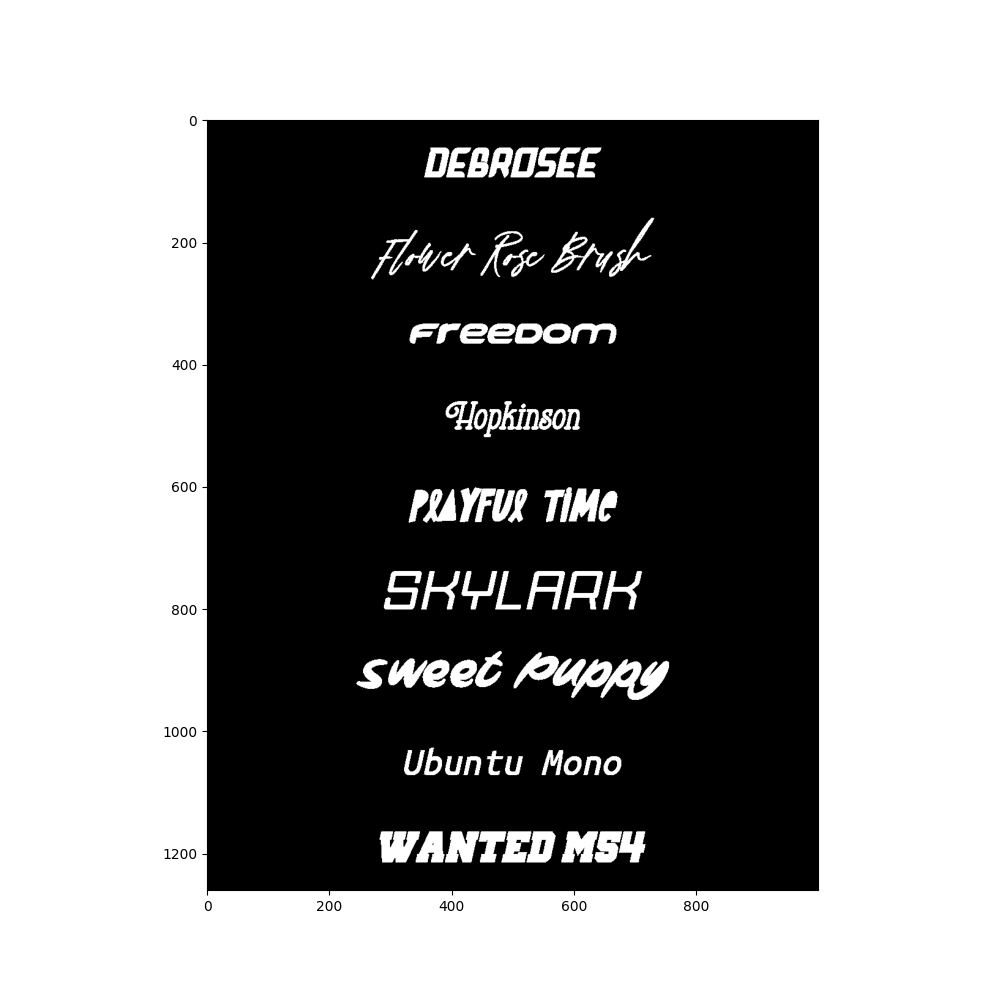

In [15]:
plt.figure(figsize=(10,10))
plt.imshow(im)

# create data sets

In [ ]:
k = keys[0]
print(db['data'][k].attrs['charBB'].shape)
print(db['data'][k].attrs['font'].shape)
print(db['data'][k].attrs['wordBB'].shape)
print(db['data'][k].attrs['txt'])
print(db['data'][k].attrs['word_font'])

In [ ]:
len(''.join([s for s in db['data'][k].attrs['txt'].tolist()]))

In [ ]:
''.join(str(db['data'][k].attrs['txt'].tolist()))

In [ ]:
train_file = 'results/train.h5'
test_with_labels = 'results2/test.h5'
test_no_labels = 'results2/test.h5'

In [ ]:
train_db = h5py.File(train_file, 'w')
test_w_db = h5py.File(test_with_labels, 'w')
test_n_db = h5py.File(test_no_labels, 'w')

In [ ]:
train_db.create_group('/data')
test_w_db.create_group('/data')
test_n_db.create_group('/data')

In [ ]:
for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = db['data'][k][:]
    if inx < 500:
        test_w_db['data'].create_dataset(k,data=im)
        test_w_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        test_w_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        test_w_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
        test_w_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

        test_n_db['data'].create_dataset(k,data=im)
        test_n_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        test_n_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        test_n_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
#         test_n_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

    else:
        train_db['data'].create_dataset(k,data=im)
        train_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        train_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        train_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
        train_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

1485 / 1664
1486 / 1664
1487 / 1664
1488 / 1664
1489 / 1664
1490 / 1664
1491 / 1664
1492 / 1664
1493 / 1664
1494 / 1664
1495 / 1664
1496 / 1664
1497 / 1664
1498 / 1664
1499 / 1664
1500 / 1664
1501 / 1664
1502 / 1664
1503 / 1664
1504 / 1664
1505 / 1664
1506 / 1664
1507 / 1664
1508 / 1664
1509 / 1664
1510 / 1664
1511 / 1664
1512 / 1664
1513 / 1664
1514 / 1664
1515 / 1664
1516 / 1664
1517 / 1664
1518 / 1664
1519 / 1664
1520 / 1664
1521 / 1664
1522 / 1664
1523 / 1664
1524 / 1664
1525 / 1664
1526 / 1664
1527 / 1664
1528 / 1664
1529 / 1664
1530 / 1664
1531 / 1664
1532 / 1664
1533 / 1664
1534 / 1664
1535 / 1664
1536 / 1664
1537 / 1664
1538 / 1664
1539 / 1664
1540 / 1664
1541 / 1664
1542 / 1664
1543 / 1664
1544 / 1664
1545 / 1664
1546 / 1664
1547 / 1664
1548 / 1664
1549 / 1664
1550 / 1664
1551 / 1664
1552 / 1664
1553 / 1664
1554 / 1664
1555 / 1664
1556 / 1664
1557 / 1664
1558 / 1664
1559 / 1664
1560 / 1664
1561 / 1664
1562 / 1664
1563 / 1664
1564 / 1664
1565 / 1664
1566 / 1664
1567 / 1664
1568

In [ ]:
train_db.close()
test_w_db.close()
test_n_db.close()

In [ ]:
test_with_labels = "results2/test_withLabels.h5"
train_fn = "results2/train.h5"

test_no_labels = "results2/test.h5"

test_w_db = h5py.File(test_with_labels, 'r')
test_n_db = h5py.File(test_no_labels, 'w')

In [ ]:
test_n_db.create_group('/data')

keys = list(test_w_db['data'].keys())

In [ ]:
for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = test_w_db['data'][k][:]

    test_n_db['data'].create_dataset(k, data=im)
    test_n_db['data'][k].attrs['charBB'] = test_w_db['data'][k].attrs['charBB']
    test_n_db['data'][k].attrs['wordBB'] = test_w_db['data'][k].attrs['wordBB']        
    test_n_db['data'][k].attrs['txt'] = test_w_db['data'][k].attrs['txt']
#         test_n_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

test_n_db.close()

In [ ]:
import re

# fix encoding of font names
fn = "results2/test_withLabels.h5"
fix = "results2/test_with_labels.h5"
# train_fn = "results2/train.h5"
# train_fix = "results/train.h5"


db = h5py.File(fn, 'r')
fix_db = h5py.File(fix, 'w')

fix_db.create_group('/data')

keys = list(db['data'].keys())

for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = db['data'][k][:]

    fix_db['data'].create_dataset(k, data=im)
    fix_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
    fix_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
    fix_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
    fonts = db['data'][k].attrs['font']
    fix_db['data'][k].attrs['font'] = [re.sub(' +', ' ',f.decode("UTF-8")) for f in fonts]
    

fix_db.close()

# sample submission file

In [ ]:

fix_db.close()

In [ ]:
train_fn = "results2/train.h5"

db = h5py.File(train_fn, 'r')
keys = list(db['data'].keys())
len(keys)